## 1. Cài đặt thư viện

In [1]:
!pip install -q openai-whisper torch torchaudio pytorch-lightning transformers librosa jiwer soundfile numpy tqdm datasets==2.18.0 tensorboardX

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 40.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 51.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.


## 2. Import các thư viện

In [2]:
import os
import torch
import torchaudio
import torchaudio.transforms as at
import numpy as np
from pathlib import Path
import whisper
import jiwer
import time
import random
from torch import nn
from torch.utils.data import Dataset, DataLoader
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

Device: cuda
GPU: Tesla T4
CUDA Version: 12.8


## 3. Chuẩn bị dữ liệu

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
vivos = load_dataset("vivos", "vivos", split="train", trust_remote_code=True)

vivos = vivos.map(lambda x: {"sentence": x["sentence"].lower()})
vivos = vivos.rename_column("sentence", "transcription")

print("Vivos dataset loaded and transcripts normalized to lowercase.")
sample = vivos[0]
print("vivos sample keys:", sample.keys())
print("vivos Transcript:", sample["transcription"])
print("vivos Audio:", sample["audio"])

Vivos dataset loaded and transcripts normalized to lowercase.
vivos sample keys: dict_keys(['speaker_id', 'path', 'audio', 'transcription'])
vivos Transcript: tình yêu thương thật sự sự kiên trì và lí tưởng tốt đẹp nhất định sẽ chiến thắng tất cả trong đó có cả đói nghèo và lạc hậu
vivos Audio: {'path': 'vivos/train/waves/VIVOSSPK27/VIVOSSPK27_066.wav', 'array': array([0.        , 0.        , 0.        , ..., 0.01083374, 0.0128479 ,
       0.01464844]), 'sampling_rate': 16000}


In [6]:
lsvsc = load_dataset("doof-ferb/LSVSC", split="train", trust_remote_code=True)

print("LSVSC dataset loaded.")
lsvsc_sample = lsvsc[0]
print("LSVSC sample keys:", lsvsc_sample.keys())
print("LSVSC Transcript:", lsvsc_sample["transcription"])
print("LSVSC Audio:", lsvsc_sample["audio"])

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/45458 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5682 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5683 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

LSVSC dataset loaded.
LSVSC sample keys: dict_keys(['audio', 'transcription', 'topic', 'gender', 'dialect', 'emotion', 'age'])
LSVSC Transcript: Thưa các bạn, để có thể nhanh chóng biết tin về toàn bộ tình hình xảy ra, Bô khâu ở trong phòng nhân viên đợi cờ rê mơ trở về
LSVSC Audio: {'path': '00000.wav', 'array': array([-0.00085449, -0.00143433, -0.00094604, ..., -0.00415039,
       -0.00357056, -0.00296021]), 'sampling_rate': 16000}


In [7]:
vlsp = load_dataset("doof-ferb/vlsp2020_vinai_100h", split="train", trust_remote_code=True)

shuffled_vlsp_indices = list(range(len(vlsp)))
random.seed(42)
random.shuffle(shuffled_vlsp_indices)

test_vlsp_indices = shuffled_vlsp_indices[:200]
train_val_vlsp_indices = shuffled_vlsp_indices[200:]

test_vlsp = vlsp.select(test_vlsp_indices)
vlsp = vlsp.select(train_val_vlsp_indices)

print("VLSP dataset loaded.")
vlsp_sample = vlsp[0]
print("VLSP sample keys:", vlsp_sample.keys())
print("VLSP Transcript:", vlsp_sample["transcription"])
print("VLSP Audio:", vlsp_sample["audio"])

Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/56427 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/23 [00:00<?, ?it/s]

VLSP dataset loaded.
VLSP sample keys: dict_keys(['audio', 'transcription'])
VLSP Transcript: không gian lặng vắng mắt anh sầu em ở đâu
VLSP Audio: {'path': 'spkyut-20190730-utt000004200.wav', 'array': array([ 0.06027222,  0.02185059, -0.00692749, ...,  0.12313843,
        0.13970947,  0.11999512]), 'sampling_rate': 16000}


In [8]:
sampled_vivos = vivos
sampled_lsvsc = lsvsc
sampled_vlsp  = vlsp

print(f"Number of vivos samples: {len(sampled_vivos)}")
print(f"Number of LSVSC samples: {len(sampled_lsvsc)}")
print(f"Number of VLSP samples: {len(sampled_vlsp)}")

Number of vivos samples: 11660
Number of LSVSC samples: 45458
Number of VLSP samples: 56227


In [9]:
from datasets import concatenate_datasets, Audio

vivos = sampled_vivos.cast_column("audio", Audio(sampling_rate=16000))
lsvsc = sampled_lsvsc.cast_column("audio", Audio(sampling_rate=16000))
vlsp = sampled_vlsp.cast_column("audio", Audio(sampling_rate=16000))

combined_dataset = concatenate_datasets([vivos, lsvsc, vlsp])

def filter_duration(example):
    audio_array = example["audio"]["array"]
    sampling_rate = example["audio"]["sampling_rate"]
    duration = len(audio_array) / sampling_rate
    return 1.0 <= duration <= 30.0

print(f"Số lượng mẫu trước khi lọc: {len(combined_dataset)}")
combined_dataset = combined_dataset.filter(filter_duration)
print(f"Số lượng mẫu sau khi lọc: {len(combined_dataset)}")

Số lượng mẫu trước khi lọc: 113345


Filter:   0%|          | 0/113345 [00:00<?, ? examples/s]

Số lượng mẫu sau khi lọc: 112304


## 4. Định nghĩa Dataset và DataCollator

In [10]:
def load_wave(wave_path, sample_rate=16000):
    waveform, sr = torchaudio.load(wave_path, normalize=True)
    if sample_rate != sr:
        waveform = at.Resample(sr, sample_rate)(waveform)
    return waveform.squeeze()


class WhisperDataCollatorWithPadding:
    def __call__(self, features):
        input_ids, labels, dec_input_ids, texts = [], [], [], []

        for f in features:
            input_ids.append(f["input_ids"])
            labels.append(f["labels"])
            dec_input_ids.append(f["dec_input_ids"])
            texts.append(f["text"])

        input_ids = torch.concat([input_id[None, :] for input_id in input_ids])

        label_lengths = [len(lab) for lab in labels]
        dec_input_ids_length = [len(e) for e in dec_input_ids]
        max_label_len = max(label_lengths + dec_input_ids_length)

        labels = [
            np.pad(lab, (0, max_label_len - lab_len), "constant", constant_values=-100)
            for lab, lab_len in zip(labels, label_lengths)
        ]
        dec_input_ids = [
            np.pad(e, (0, max_label_len - e_len), "constant", constant_values=50257)
            for e, e_len in zip(dec_input_ids, dec_input_ids_length)
        ]

        batch = {
            k: torch.tensor(np.array(v), requires_grad=False)
            for k, v in {"labels": labels, "dec_input_ids": dec_input_ids}.items()
        }
        batch["input_ids"] = input_ids
        batch["texts"] = texts
        return batch


class WhisperDataset(Dataset):
    def __init__(self, hf_dataset, sample_rate=16000, language="vi"):
        self.hf_dataset = hf_dataset
        self.sample_rate = sample_rate
        self.language = language

        self.tokenizer = whisper.tokenizer.get_tokenizer(
            multilingual=True,
            language=language,
            task="transcribe"
        )

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        sample = self.hf_dataset[idx]
        audio_array = sample["audio"]["array"]

        text = None
        if "sentence" in sample and sample["sentence"] is not None:
            text = sample["sentence"]
        elif "transcription" in sample and sample["transcription"] is not None:
            text = sample["transcription"]

        if text is None:
            print(f"Warning: No valid text found.")
            text = ""

        if sample["audio"]["sampling_rate"] != self.sample_rate:
            resampler = at.Resample(sample["audio"]["sampling_rate"], self.sample_rate)
            audio = resampler(torch.tensor(audio_array).float())
        else:
            audio = torch.tensor(audio_array).float()

        audio = whisper.pad_or_trim(audio.numpy())
        mel = whisper.log_mel_spectrogram(audio)

        text_token = [
            *self.tokenizer.sot_sequence_including_notimestamps
        ] + self.tokenizer.encode(text)
        labels = text_token[1:] + [self.tokenizer.eot]

        if len(text_token) >= 448:
            text_token = text_token[:448]
            labels = labels[:448]

        return {
            "input_ids": mel,
            "labels": np.array(labels, dtype=np.int64),
            "dec_input_ids": np.array(text_token, dtype=np.int64),
            "text": text,
        }

## 5. Định nghĩa mô hình training

In [11]:
class WhisperModelModule(LightningModule):
    def __init__(
        self,
        model_name="small",
        learning_rate=1e-5,
        weight_decay=0.01,
        warmup_steps=10,
        language="vi",
    ):
        super().__init__()
        self.save_hyperparameters()

        self.model = whisper.load_model(model_name)
        self.tokenizer = whisper.tokenizer.get_tokenizer(
            multilingual=True,
            language=language,
            task="transcribe"
        )

        for p in self.model.encoder.parameters():
            p.requires_grad = False

        self.loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_id):
        input_ids = batch["input_ids"]
        labels = batch["labels"].long()
        dec_input_ids = batch["dec_input_ids"].long()

        with torch.no_grad():
            audio_features = self.model.encoder(input_ids)

        out = self.model.decoder(dec_input_ids, audio_features)
        loss = self.loss_fn(out.view(-1, out.size(-1)), labels.view(-1))

        self.log("train/loss", loss, on_step=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_id):
        input_ids = batch["input_ids"]
        labels = batch["labels"].long()
        dec_input_ids = batch["dec_input_ids"].long()
        texts = batch["texts"]

        audio_features = self.model.encoder(input_ids)
        out = self.model.decoder(dec_input_ids, audio_features)
        loss = self.loss_fn(out.view(-1, out.size(-1)), labels.view(-1))

        options = whisper.DecodingOptions(language="vi", without_timestamps=True)
        results = self.model.decode(audio_features, options)
        preds = [res.text.lower() for res in results]
        refs = [t.lower() for t in texts]

        wer = jiwer.wer(refs, preds)

        self.log("val/loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val/wer", wer, on_step=False, on_epoch=True, prog_bar=True)

        return {"loss": loss, "wer": wer}

    def configure_optimizers(self):
        model = self.model
        no_decay = ["bias", "LayerNorm.weight"]
        optimizer_grouped_parameters = [
            {
                "params": [
                    p for n, p in model.named_parameters()
                    if not any(nd in n for nd in no_decay)
                ],
                "weight_decay": self.hparams.weight_decay,
            },
            {
                "params": [
                    p for n, p in model.named_parameters()
                    if any(nd in n for nd in no_decay)
                ],
                "weight_decay": 0.0,
            },
        ]
        optimizer = AdamW(optimizer_grouped_parameters, lr=self.hparams.learning_rate, eps=1e-8)
        return optimizer

## 6. Tạo dataset và dataloader

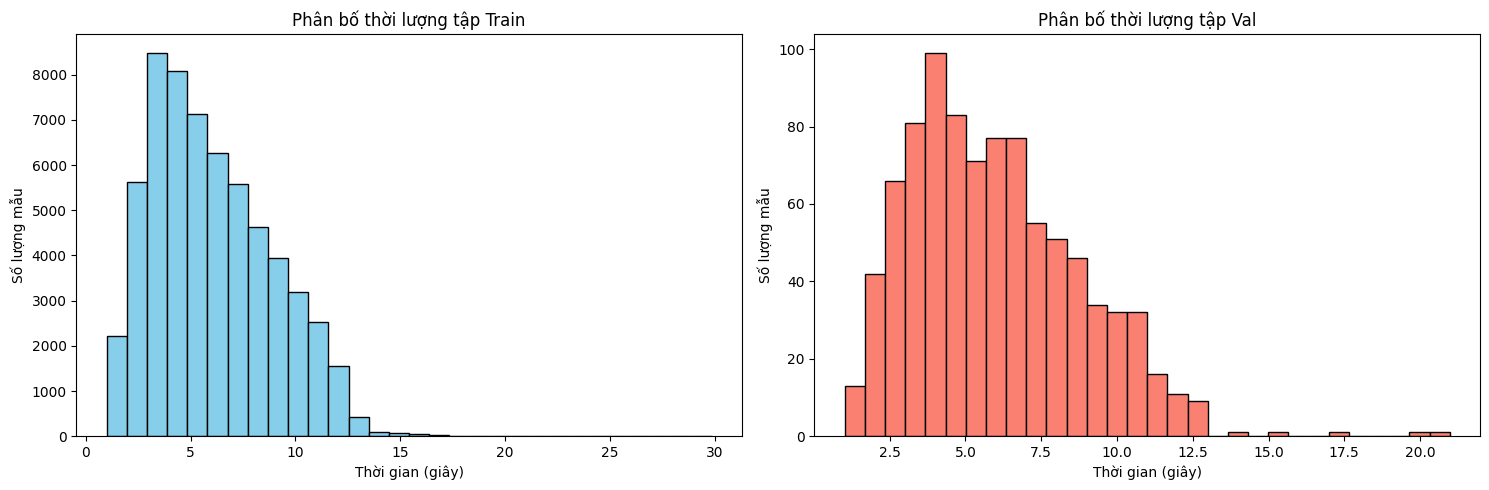

Train set: 100.89 giờ (60000 mẫu)
Val set:   1.50 giờ (900 mẫu)


In [12]:
CONFIG = {
    "model_name": "small",
    "batch_size": 8,
    "gradient_accumulation": 2,
    "max_steps": 20000,
    "val_check_interval": 1000,
    "learning_rate": 1e-5,
    "num_workers": 3,
    "language": "vi",
    "sample_rate": 16000,
}

from datasets import Audio, concatenate_datasets
from torch.utils.data import Subset, random_split
import random
import torch
import matplotlib.pyplot as plt

full_dataset = WhisperDataset(
    hf_dataset=combined_dataset,
    sample_rate=CONFIG["sample_rate"],
    language=CONFIG["language"]
)

total_samples = len(full_dataset)
indices = list(range(total_samples))
random.shuffle(indices)
subset_indices = indices[:60900]
subset = Subset(full_dataset, subset_indices)

train_dataset, val_dataset = random_split(
    subset,
    [60000, 900],
    generator=torch.Generator().manual_seed(42)
)

def get_durations(dataset_subset):
    durations = []
    for idx in dataset_subset.indices:
        audio_info = combined_dataset[idx]["audio"]
        duration = len(audio_info["array"]) / audio_info["sampling_rate"]
        durations.append(duration)
    return durations

train_durations = get_durations(train_dataset)
val_durations = get_durations(val_dataset)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(train_durations, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title("Phân bố thời lượng tập Train")
axes[0].set_xlabel("Thời gian (giây)")
axes[0].set_ylabel("Số lượng mẫu")

axes[1].hist(val_durations, bins=30, color='salmon', edgecolor='black')
axes[1].set_title("Phân bố thời lượng tập Val")
axes[1].set_xlabel("Thời gian (giây)")
axes[1].set_ylabel("Số lượng mẫu")

plt.tight_layout()
plt.show()

print(f"Train set: {sum(train_durations)/3600:.2f} giờ ({len(train_dataset)} mẫu)")
print(f"Val set:   {sum(val_durations)/3600:.2f} giờ ({len(val_dataset)} mẫu)")

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
    collate_fn=WhisperDataCollatorWithPadding(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
    collate_fn=WhisperDataCollatorWithPadding(),
)

In [13]:
import gc
import torch
from datasets import load_dataset, Audio, concatenate_datasets

test_vivos = load_dataset("vivos", "vivos", split="test[:200]", trust_remote_code=True)
test_vivos = test_vivos.map(lambda x: {"sentence": x["sentence"].lower()})
test_vivos = test_vivos.rename_column("sentence", "transcription")

test_lsvsc = load_dataset("doof-ferb/LSVSC", split="test[:200]", trust_remote_code=True)

test_vivos = test_vivos.cast_column("audio", Audio(sampling_rate=16000))
test_lsvsc = test_lsvsc.cast_column("audio", Audio(sampling_rate=16000))
test_vlsp = test_vlsp.cast_column("audio", Audio(sampling_rate=16000))

final_test_dataset = concatenate_datasets([test_vivos, test_lsvsc, test_vlsp])
final_test_dataset = final_test_dataset.filter(filter_duration)
print(f"Số lượng mẫu tập Test: {len(final_test_dataset)} mẫu")

vars_to_del = ['vivos', 'lsvsc', 'vlsp', 'sampled_vivos', 'sampled_lsvsc', 'sampled_vlsp', 'combined_dataset']
for var in vars_to_del:
    if var in locals():
        del locals()[var]

gc.collect()
torch.cuda.empty_cache()

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Filter:   0%|          | 0/600 [00:00<?, ? examples/s]

Số lượng mẫu tập Test: 591 mẫu


## 7. Test một batch dữ liệu

In [14]:
batch = next(iter(train_loader))
print(f"Batch keys: {batch.keys()}")
print(f"Input IDs shape: {batch['input_ids'].shape}")
print(f"Labels shape: {batch['labels'].shape}")
print(f"Dec input IDs shape: {batch['dec_input_ids'].shape}")
print(f"Sample text: {batch['texts'][0]}")

Batch keys: dict_keys(['labels', 'dec_input_ids', 'input_ids', 'texts'])
Input IDs shape: torch.Size([8, 80, 3000])
Labels shape: torch.Size([8, 83])
Dec input IDs shape: torch.Size([8, 83])
Sample text: một trí thức trẻ


## 8. Fine-tune mô hình

In [15]:
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("logs", exist_ok=True)

model = WhisperModelModule(
    model_name=CONFIG["model_name"],
    learning_rate=CONFIG["learning_rate"],
    language=CONFIG["language"],
)

checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints",
    filename="whisper-step{step:02d}-{val/wer:.4f}",
    save_top_k=3,
    monitor="val/wer",
    mode="min",
    every_n_train_steps=CONFIG["val_check_interval"],
)

early_stop_callback = EarlyStopping(
    monitor="val/wer",
    patience=3,
    mode="min",
    verbose=True
)

lr_callback = LearningRateMonitor(logging_interval="step")
logger = TensorBoardLogger("logs", name="whisper_finetune")

trainer = Trainer(
    max_steps=CONFIG["max_steps"],
    val_check_interval=CONFIG["val_check_interval"],
    callbacks=[checkpoint_callback, lr_callback, early_stop_callback],
    logger=logger,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision=16,
    gradient_clip_val=1.0,
    accumulate_grad_batches=CONFIG["gradient_accumulation"],
    log_every_n_steps=500
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

100%|███████████████████████████████████████| 461M/461M [00:06<00:00, 71.9MiB/s]
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Whisper          │  240 M │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 153 M                                                                                            
Non-trainable params: 87.0 M                                                                                       
Total params: 240 M                                                                                                
Total estimated model params size (MB): 962                                                                        
Modules in train mode: 371                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.callbacks.early_stopping:Metric val/wer improved. New best score: 0.205
INFO:pytorch_lightning.callbacks.early_stopping:Metric val/wer improved by 0.028 >= min_delta = 0.0. New best score: 0.177
INFO:pytorch_lightning.callbacks.early_stopping:Metric val/wer improved by 0.004 >= min_delta = 0.0. New best score: 0.172
INFO:pytorch_lightning.callbacks.early_stopping:Metric val/wer improved by 0.009 >= min_delta = 0.0. New best score: 0.164
INFO:pytorch_lightning.callbacks.early_stopping:Metric val/wer improved by 0.005 >= min_delta = 0.0. New best score: 0.158
INFO:pytorch_lightning.callbacks.early_stopping:Metric val/wer improved by 0.009 >= min_delta = 0.0. New best score: 0.149
INFO:pytorch_lightning.callbacks.early_stopping:Metric val/wer improved by 0.000 >= min_delta = 0.0. New best score: 0.149
INFO:pytorch_lightning.callbacks.early_stopping:Metric val/wer improved by 0.008 >= min_delta = 0.0. New best score: 0.141
INFO:pytorch_lightning.callbacks.early_stopp

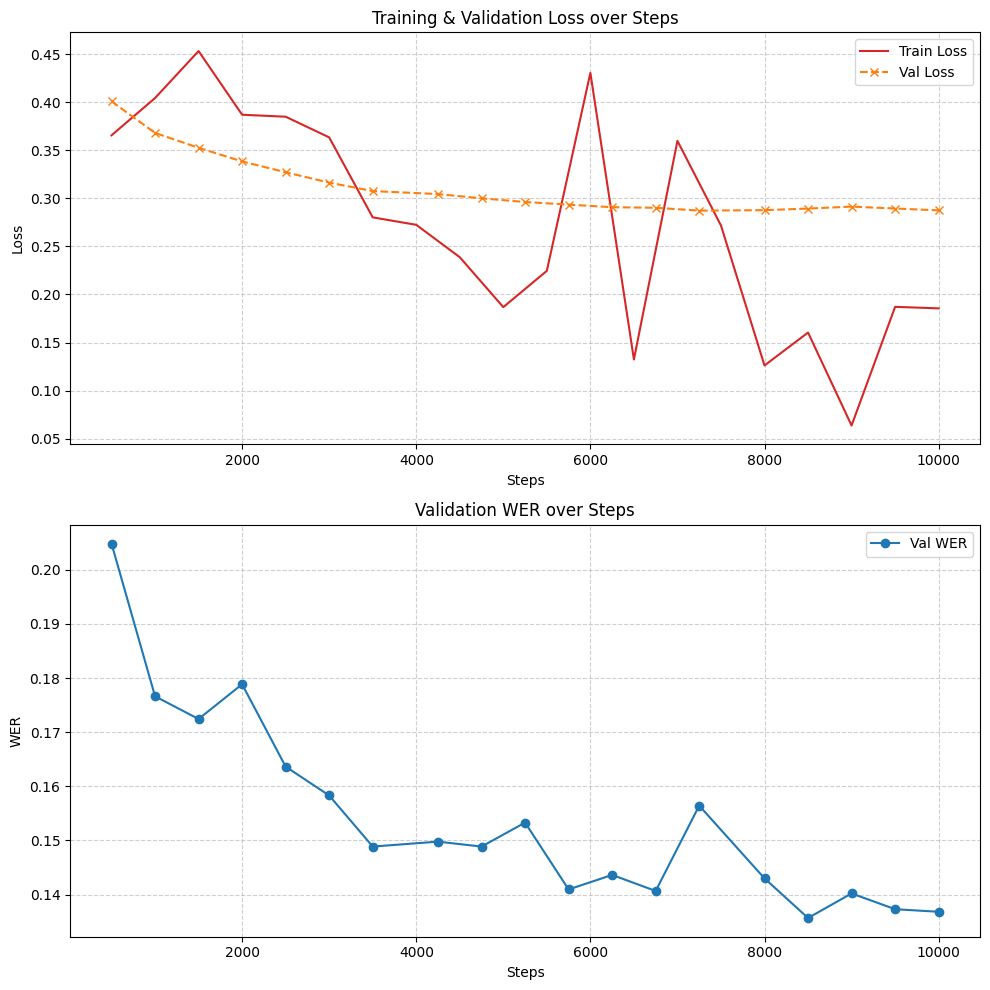

In [23]:
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator
import os

def plot_whisper_metrics(log_dir):
    subdirs = [os.path.join(log_dir, d) for d in os.listdir(log_dir) if os.path.isdir(os.path.join(log_dir, d))]
    if not subdirs:
        print("Chưa có dữ liệu log trong thư mục.")
        return
    latest_log = max(subdirs, key=os.path.getmtime)

    ea = event_accumulator.EventAccumulator(latest_log)
    ea.Reload()

    train_loss = [(scalar.step, scalar.value) for scalar in ea.Scalars('train/loss')]
    val_loss = [(scalar.step, scalar.value) for scalar in ea.Scalars('val/loss')]
    val_wer = [(scalar.step, scalar.value) for scalar in ea.Scalars('val/wer')]

    steps_loss, values_loss = zip(*train_loss)
    steps_val_loss, values_val_loss = zip(*val_loss)
    steps_wer, values_wer = zip(*val_wer)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

    ax1.plot(steps_loss, values_loss, color='tab:red', label='Train Loss')
    ax1.plot(steps_val_loss, values_val_loss, color='tab:orange', linestyle='--', marker='x', label='Val Loss')
    ax1.set_title('Training & Validation Loss over Steps')
    ax1.set_xlabel('Steps')
    ax1.set_ylabel('Loss')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    ax2.plot(steps_wer, values_wer, color='tab:blue', marker='o', label='Val WER')
    ax2.set_title('Validation WER over Steps')
    ax2.set_xlabel('Steps')
    ax2.set_ylabel('WER')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

if os.path.exists("logs/whisper_finetune"):
    plot_whisper_metrics("logs/whisper_finetune")

### 9. Lưu mô hình

In [20]:
import torch
import os

best_checkpoint = "/content/checkpoints/whisper-stepstep=9000-val/wer=0.1357.ckpt"

if os.path.exists(best_checkpoint):
    checkpoint = torch.load(best_checkpoint, map_location="cpu")
    state_dict = checkpoint["state_dict"]

    new_state_dict = {k.replace("model.", ""): v for k, v in state_dict.items()}

    save_path = "/content/drive/MyDrive/whisper_finetuned.pt"
    torch.save(new_state_dict, save_path)
    print(f"Đã lưu mô hình tinh chỉnh thành công tại: {save_path}")
else:
    print(f"Lỗi: Không tìm thấy file tại {best_checkpoint}")

Đã lưu mô hình tinh chỉnh thành công tại: /content/drive/MyDrive/whisper_finetuned.pt


## 10. Import mô hình

In [21]:
import whisper
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_medium = whisper.load_model('medium').to(device)
model_medium.eval()

model_original_small = whisper.load_model('small').to(device)
model_original_small.eval()

model_finetuned_small = whisper.load_model('small')
ft_path = '/content/drive/MyDrive/whisper_finetuned.pt'
if os.path.exists(ft_path):
    state_dict = torch.load(ft_path, map_location='cpu')
    model_finetuned_small.load_state_dict(state_dict)
    model_finetuned_small.to(device)
    model_finetuned_small.eval()

100%|█████████████████████████████████████| 1.42G/1.42G [00:59<00:00, 25.5MiB/s]


## 11. So sánh wer

In [22]:
import pandas as pd
import time
from tqdm import tqdm

def evaluate_model(model, dataset, model_label):
    model.eval()
    preds = []
    refs = []
    start_time = time.time()

    options = whisper.DecodingOptions(language="vi", without_timestamps=True)

    for i in tqdm(range(len(dataset)), desc=f"Evaluating {model_label}"):
        sample = dataset[i]
        audio_array = sample["audio"]["array"]
        audio = torch.from_numpy(audio_array).float()
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio).to(device)

        with torch.no_grad():
            result = model.decode(mel, options)
            preds.append(result.text.lower())
            refs.append(sample["transcription"].lower())

    end_time = time.time()
    avg_time = (end_time - start_time) / len(dataset)
    wer = jiwer.wer(refs, preds)

    return {"Model": model_label, "WER": f"{wer:.4f}", "Avg Time (s)": f"{avg_time:.4f}"}

results = []

results.append(evaluate_model(model_finetuned_small, final_test_dataset, "Whisper Small FT"))

results.append(evaluate_model(model_original_small, final_test_dataset, "Whisper Small Original"))

results.append(evaluate_model(model_medium, final_test_dataset, "Whisper Medium Original"))

df_comparison = pd.DataFrame(results)
print("\nBẢNG SO SÁNH HIỆU NĂNG TRÊN TẬP TEST")
print(df_comparison.to_string(index=False))

Evaluating Whisper Medium Original: 100%|██████████| 591/591 [14:53<00:00,  1.51s/it]


BẢNG SO SÁNH HIỆU NĂNG TRÊN TẬP TEST
                  Model    WER Avg Time (s)
       Whisper Small FT 0.1329       0.7542
 Whisper Small Original 0.2710       0.7631
Whisper Medium Original 0.2440       1.5126


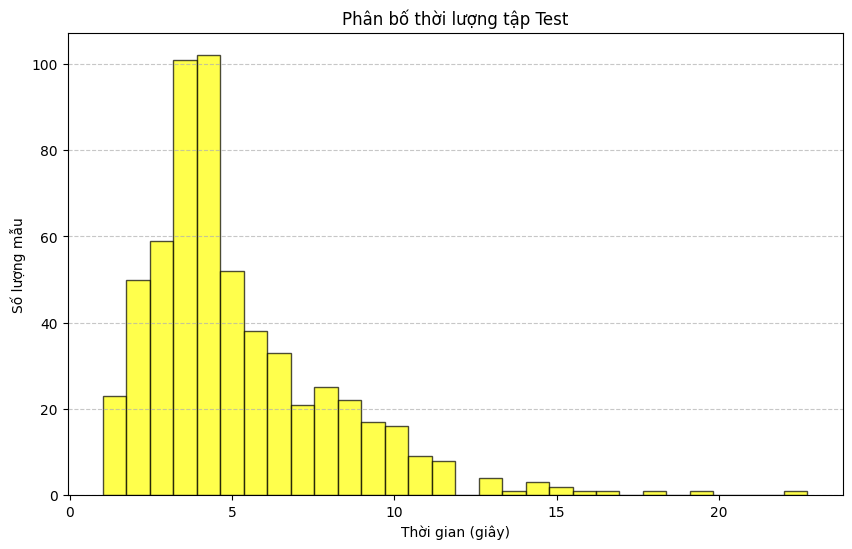

Tổng thời lượng tập test: 0.85 giờ
Thời lượng trung bình: 5.20 giây


In [25]:
import matplotlib.pyplot as plt

def plot_test_durations(dataset):
    durations = []
    for sample in dataset:
        audio_array = sample["audio"]["array"]
        sr = sample["audio"]["sampling_rate"]
        durations.append(len(audio_array) / sr)

    plt.figure(figsize=(10, 6))
    plt.hist(durations, bins=30, color='yellow', edgecolor='black', alpha=0.7)
    plt.title("Phân bố thời lượng tập Test")
    plt.xlabel("Thời gian (giây)")
    plt.ylabel("Số lượng mẫu")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    print(f"Tổng thời lượng tập test: {sum(durations)/3600:.2f} giờ")
    print(f"Thời lượng trung bình: {sum(durations)/len(durations):.2f} giây")

if 'final_test_dataset' in locals():
    plot_test_durations(final_test_dataset)
else:
    print("Không tìm thấy biến 'final_test_dataset'. Vui lòng chạy các cell chuẩn bị tập test trước.")